# PCB Defect Detection — Dataset Exploration
Run this notebook after `python scripts/prepare_dataset.py` to verify the dataset.

In [3]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from collections import Counter

SPLITS_DIR = Path('../data/splits')
CLASS_NAMES = ['missing_hole', 'mouse_bite', 'open_circuit', 'short', 'spur', 'spurious_copper']
COLORS = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db','#9b59b6']

## 1. Split sizes

In [5]:
for split in ['train', 'val', 'test']:
    imgs = list((SPLITS_DIR / split / 'images').glob('*.jpg'))
    lbls = list((SPLITS_DIR / split / 'labels').glob('*.txt'))
    print(f'{split:>5}: {len(imgs)} images | {len(lbls)} labels')

train: 0 images | 0 labels
  val: 0 images | 0 labels
 test: 0 images | 0 labels


## 2. Class distribution

/var/folders/ql/xjvpd9nx1zv1qqnlxpmj3h1w0000gn/T/ipykernel_9670/559108732.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


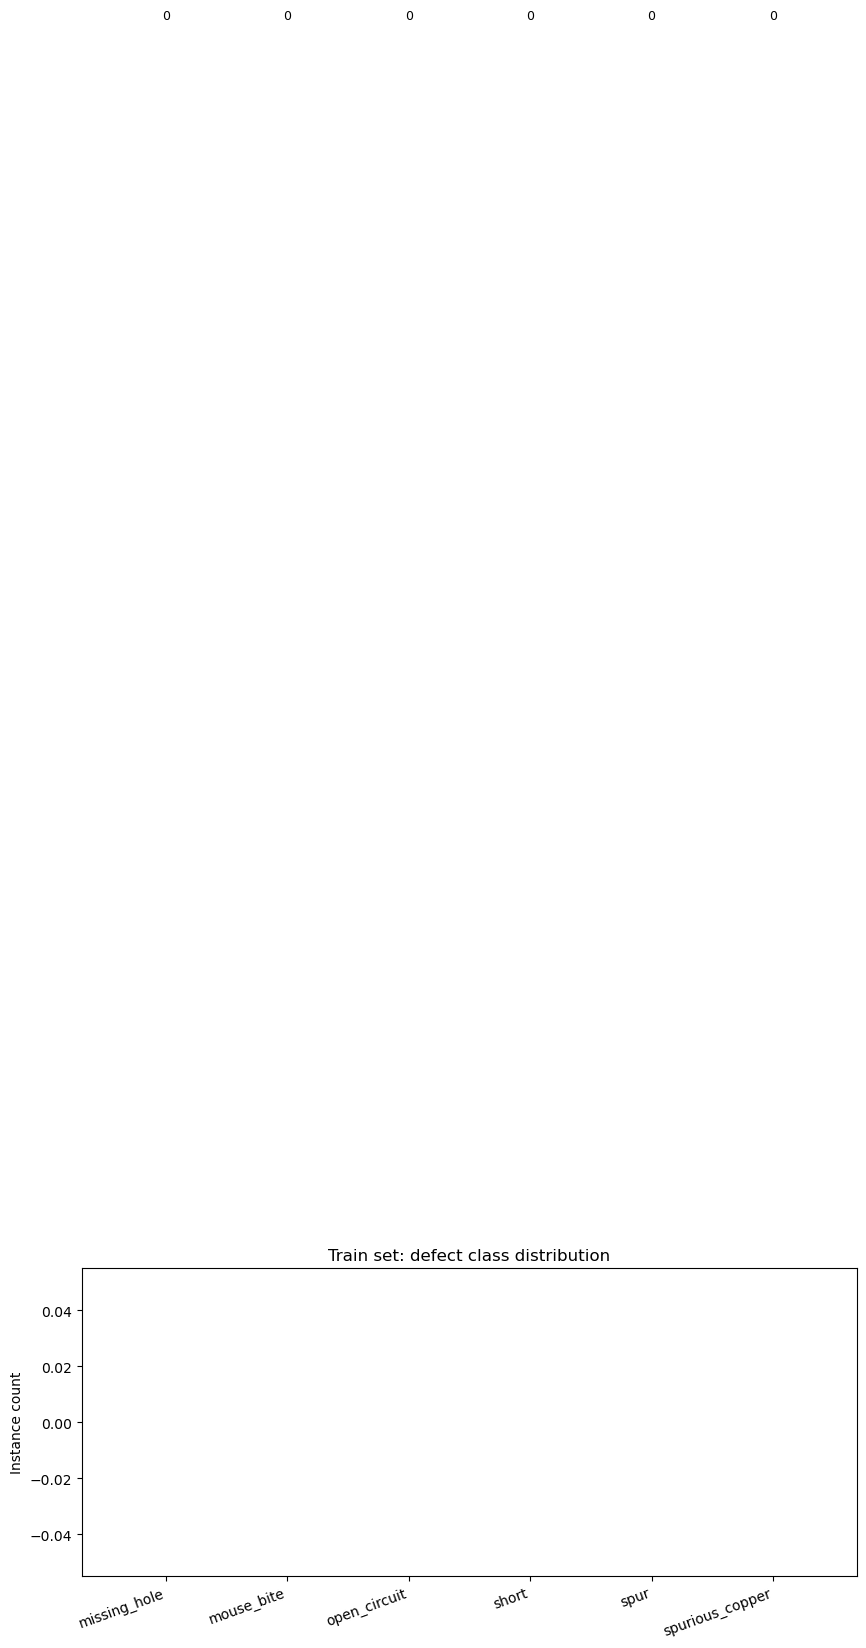

Total instances: 0


In [7]:
counter = Counter()
for lbl_file in (SPLITS_DIR / 'train' / 'labels').glob('*.txt'):
    for line in lbl_file.read_text().strip().splitlines():
        cls_id = int(line.split()[0])
        counter[cls_id] += 1

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(CLASS_NAMES)), [counter[i] for i in range(len(CLASS_NAMES))], color=COLORS)
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right')
ax.set_ylabel('Instance count')
ax.set_title('Train set: defect class distribution')
for bar, val in zip(bars, [counter[i] for i in range(len(CLASS_NAMES))]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
print('Total instances:', sum(counter.values()))

## 3. Visualise random samples with bounding boxes

In [ ]:
def draw_boxes(img_path, lbl_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(img)

    for line in lbl_path.read_text().strip().splitlines():
        cls_id, cx, cy, bw, bh = map(float, line.split())
        cls_id = int(cls_id)
        x = (cx - bw/2) * w
        y = (cy - bh/2) * h
        rect = patches.Rectangle((x, y), bw*w, bh*h,
                                   linewidth=2, edgecolor=COLORS[cls_id], facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y - 4, CLASS_NAMES[cls_id], color=COLORS[cls_id], fontsize=8, fontweight='bold')

    ax.set_title(img_path.name)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

samples = random.sample(list((SPLITS_DIR / 'train' / 'images').glob('*.jpg')), 4)
for img_path in samples:
    lbl_path = SPLITS_DIR / 'train' / 'labels' / (img_path.stem + '.txt')
    if lbl_path.exists():
        draw_boxes(img_path, lbl_path)

## 4. Bounding box size distribution

In [ ]:
widths, heights = [], []
for lbl_file in (SPLITS_DIR / 'train' / 'labels').glob('*.txt'):
    for line in lbl_file.read_text().strip().splitlines():
        parts = list(map(float, line.split()))
        widths.append(parts[3])
        heights.append(parts[4])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=40, color='#3498db', edgecolor='white')
axes[0].set_title('Normalised bbox width distribution')
axes[0].set_xlabel('Width (relative to image)')
axes[1].hist(heights, bins=40, color='#e74c3c', edgecolor='white')
axes[1].set_title('Normalised bbox height distribution')
axes[1].set_xlabel('Height (relative to image)')
plt.tight_layout()
plt.show()
print(f'Median bbox: {np.median(widths):.3f} x {np.median(heights):.3f} (normalised)')